# VNExpress News Data Overview

VNExpress là một trong những trang báo điện tử lớn tại Việt Nam. 
Trong project này, nhóm thu thập dữ liệu từ hai chuyên mục:

- Sức khỏe
- Giải trí

Nguồn dữ liệu:

https://vnexpress.net/suc-khoe  
https://vnexpress.net/giai-tri

Mục tiêu của notebook này:

- Hiểu cấu trúc dữ liệu đã crawl
- Phân tích dữ liệu thô (raw data)
- Tìm missing values
- Phát hiện vấn đề cần xử lý trước khi clean data

## 1. Import các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import re
from collections import Counter

sns.set(style="whitegrid")

pd.set_option('display.max_columns', None)

## 2. Đọc và tìm hiểu dữ liệu

### 2.1 Đọc dữ liệu từ file CSV

In [2]:
DATA_PATH = "../data/raw_data/"

df = pd.read_csv(DATA_PATH + "vnexpress_raw_data.csv", encoding="utf-8")

print("Kích thước dataset:", df.shape)

Kích thước dataset: (1202, 11)


### 2.2 Xem vài dòng dữ liệu đầu

In [3]:
df.head()

,title,description,date,category,thumbnail,content,author,tags,group,nums_of_comments,url
0,Bộ sưu tập áo dài họa tiết ngựa của Đức Phúc,Ca sĩ Đức Phúc chọn trang phục truyền thống th...,"Thứ ba, 24/2/2026, 09:40 (GMT+7)",Thời trang,https://i1-giaitri.vnecdn.net/2026/02/23/Duc-P...,Ca sĩ đón Tết Bính Ngọ cùng gia đình và các đồ...,Tân Cao,"đức phúc, áo dài họa tiết ngựa, bính ngọ",Giải trí,0,https://vnexpress.net/39-thuoc-sinh-hoc-sap-he...
1,Bộ sưu tập áo dài họa tiết ngựa của Đức Phúc,Ca sĩ Đức Phúc chọn trang phục truyền thống th...,"Thứ ba, 24/2/2026, 09:40 (GMT+7)",Thời trang,https://i1-giaitri.vnecdn.net/2026/02/23/Duc-P...,Ca sĩ đón Tết Bính Ngọ cùng gia đình và các đồ...,Tân Cao,"đức phúc, áo dài họa tiết ngựa, bính ngọ",Giải trí,0,https://vnexpress.net/quan-quan-sing-asia-toi-...
2,Bộ sưu tập áo dài họa tiết ngựa của Đức Phúc,Ca sĩ Đức Phúc chọn trang phục truyền thống th...,"Thứ ba, 24/2/2026, 09:40 (GMT+7)",Thời trang,https://i1-giaitri.vnecdn.net/2026/02/23/Duc-P...,Ca sĩ đón Tết Bính Ngọ cùng gia đình và các đồ...,Tân Cao,"đức phúc, áo dài họa tiết ngựa, bính ngọ",Giải trí,0,https://vnexpress.net/nu-sinh-gen-z-doc-sach-d...
3,Bộ sưu tập áo dài họa tiết ngựa của Đức Phúc,Ca sĩ Đức Phúc chọn trang phục truyền thống th...,"Thứ ba, 24/2/2026, 09:40 (GMT+7)",Thời trang,https://i1-giaitri.vnecdn.net/2026/02/23/Duc-P...,Ca sĩ đón Tết Bính Ngọ cùng gia đình và các đồ...,Tân Cao,"đức phúc, áo dài họa tiết ngựa, bính ngọ",Giải trí,0,https://vnexpress.net/6-trieu-nguoi-viet-song-...
4,Bộ sưu tập áo dài họa tiết ngựa của Đức Phúc,Ca sĩ Đức Phúc chọn trang phục truyền thống th...,"Thứ ba, 24/2/2026, 09:40 (GMT+7)",Thời trang,https://i1-giaitri.vnecdn.net/2026/02/23/Duc-P...,Ca sĩ đón Tết Bính Ngọ cùng gia đình và các đồ...,Tân Cao,"đức phúc, áo dài họa tiết ngựa, bính ngọ",Giải trí,0,https://vnexpress.net/bo-suu-tap-ao-dai-hoa-ti...


### 2.3 Thông tin các cột dữ liệu

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1202 entries, 0 to 1201
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   title             1202 non-null   str  
 1   description       1202 non-null   str  
 2   date              1202 non-null   str  
 3   category          1202 non-null   str  
 4   thumbnail         1116 non-null   str  
 5   content           1202 non-null   str  
 6   author            1202 non-null   str  
 7   tags              1202 non-null   str  
 8   group             1202 non-null   str  
 9   nums_of_comments  1202 non-null   int64
 10  url               1202 non-null   str  
dtypes: int64(1), str(10)
memory usage: 103.4 KB


### 2.4 Kiểm tra dữ liệu thiếu

In [5]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing (%)": missing_percentage
})

missing_df.sort_values(by="Missing Values", ascending=False)

,Missing Values,Missing (%)
thumbnail,86,7.154742
title,0,0.000000
description,0,0.000000
date,0,0.000000
category,0,0.000000
content,0,0.000000
author,0,0.000000
tags,0,0.000000
group,0,0.000000
nums_of_comments,0,0.000000


### 2.5 Thống kê mô tả

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
nums_of_comments,1202.0,0.28203,1.780034,0.0,0.0,0.0,0.0,24.0


## 3. Phân bố dữ liệu

### 3.1 Số lượng bài viết theo nhóm

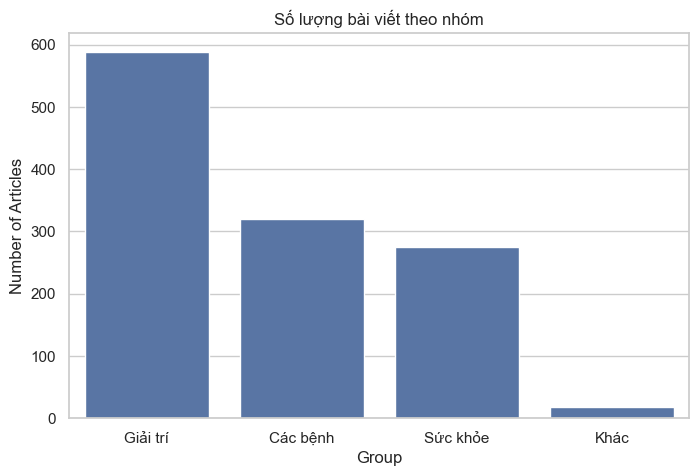

In [7]:
plt.figure(figsize=(8,5))

group_counts = df["group"].value_counts()

sns.barplot(
    x=group_counts.index,
    y=group_counts.values
)

plt.title("Số lượng bài viết theo nhóm")
plt.xlabel("Group")
plt.ylabel("Number of Articles")

plt.show()

### 3.2 Số lượng bài theo category

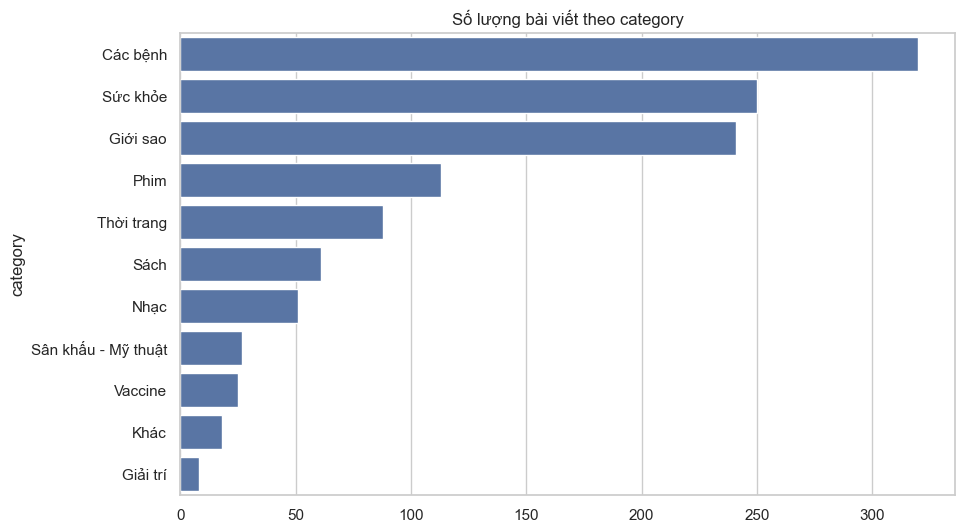

In [8]:
plt.figure(figsize=(10,6))

category_counts = df["category"].value_counts()

sns.barplot(
    y=category_counts.index,
    x=category_counts.values
)

plt.title("Số lượng bài viết theo category")

plt.show()

### 3.3 Phân bố số lượng bình luận

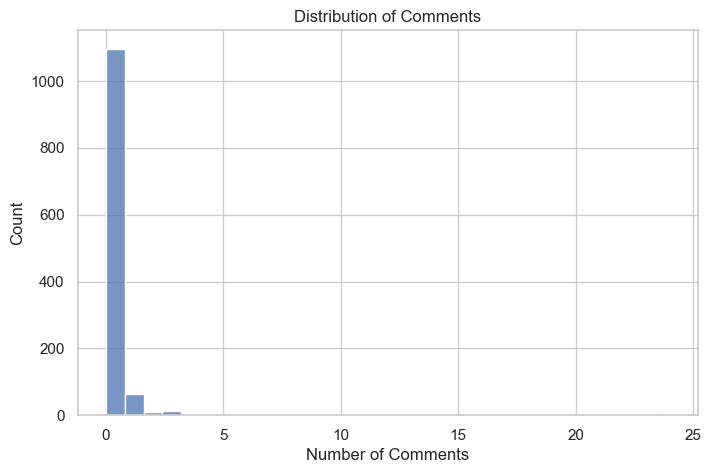

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["nums_of_comments"], bins=30)

plt.title("Distribution of Comments")

plt.xlabel("Number of Comments")

plt.show()

### 3.4 Phân tích độ dài title và content

In [10]:
df["title_length"] = df["title"].astype(str).apply(lambda x: len(x.split()))
df["content_length"] = df["content"].astype(str).apply(lambda x: len(x.split()))

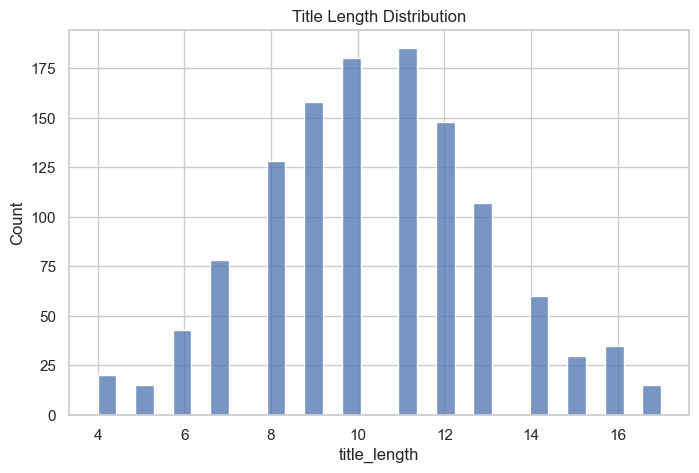

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["title_length"], bins=30)

plt.title("Title Length Distribution")

plt.show()

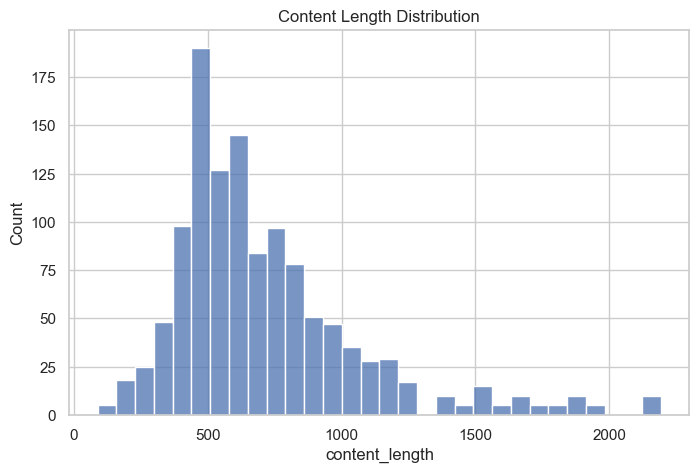

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["content_length"], bins=30)

plt.title("Content Length Distribution")

plt.show()

### 3.5 Kiểm tra bài viết bất thường

In [13]:
df.sort_values("content_length", ascending=False).head()

,title,description,date,category,thumbnail,content,author,tags,group,nums_of_comments,url,title_length,content_length
1030,'Bóng đá Việt Nam' (kỳ 2): Trận cầu mừng 25 nă...,"Đội Thể Công gỡ hòa, ghi bàn, lội ngược dòng s...","Thứ ba, 27/1/2026, 14:56 (GMT+7)",Sách,https://i1-giaitri.vnecdn.net/2026/01/14/5e0ae...,Ấn phẩmBóng đá Việt Nam (1896-2025): Ký ức và ...,"(Trích sách""Bóng đá Việt Nam (1896-2025): Ký ứ...","thể công, bóng đá việt nam, tác giả đặng hoàng...",Giải trí,0,https://vnexpress.net/tai-tu-ha-jung-woo-cong-...,13,2194
1031,'Bóng đá Việt Nam' (kỳ 2): Trận cầu mừng 25 nă...,"Đội Thể Công gỡ hòa, ghi bàn, lội ngược dòng s...","Thứ ba, 27/1/2026, 14:56 (GMT+7)",Sách,https://i1-giaitri.vnecdn.net/2026/01/14/5e0ae...,Ấn phẩmBóng đá Việt Nam (1896-2025): Ký ức và ...,"(Trích sách""Bóng đá Việt Nam (1896-2025): Ký ứ...","thể công, bóng đá việt nam, tác giả đặng hoàng...",Giải trí,0,https://vnexpress.net/6-ly-do-hit-tho-sau-tot-...,13,2194
1032,'Bóng đá Việt Nam' (kỳ 2): Trận cầu mừng 25 nă...,"Đội Thể Công gỡ hòa, ghi bàn, lội ngược dòng s...","Thứ ba, 27/1/2026, 14:56 (GMT+7)",Sách,https://i1-giaitri.vnecdn.net/2026/01/14/5e0ae...,Ấn phẩmBóng đá Việt Nam (1896-2025): Ký ức và ...,"(Trích sách""Bóng đá Việt Nam (1896-2025): Ký ứ...","thể công, bóng đá việt nam, tác giả đặng hoàng...",Giải trí,0,https://vnexpress.net/dieu-gi-xay-ra-khi-mang-...,13,2194
1034,'Bóng đá Việt Nam' (kỳ 2): Trận cầu mừng 25 nă...,"Đội Thể Công gỡ hòa, ghi bàn, lội ngược dòng s...","Thứ ba, 27/1/2026, 14:56 (GMT+7)",Sách,https://i1-giaitri.vnecdn.net/2026/01/14/5e0ae...,Ấn phẩmBóng đá Việt Nam (1896-2025): Ký ức và ...,"(Trích sách""Bóng đá Việt Nam (1896-2025): Ký ứ...","thể công, bóng đá việt nam, tác giả đặng hoàng...",Giải trí,0,https://vnexpress.net/bong-da-viet-nam-ky-2-tr...,13,2194
1033,'Bóng đá Việt Nam' (kỳ 2): Trận cầu mừng 25 nă...,"Đội Thể Công gỡ hòa, ghi bàn, lội ngược dòng s...","Thứ ba, 27/1/2026, 14:56 (GMT+7)",Sách,https://i1-giaitri.vnecdn.net/2026/01/14/5e0ae...,Ấn phẩmBóng đá Việt Nam (1896-2025): Ký ức và ...,"(Trích sách""Bóng đá Việt Nam (1896-2025): Ký ứ...","thể công, bóng đá việt nam, tác giả đặng hoàng...",Giải trí,0,https://vnexpress.net/tranh-tai-hien-can-long-...,13,2194


## 4. Nhận xét về dữ liệu raw

Qua quá trình phân tích dữ liệu thô:

- Dataset gồm các bài viết từ hai chuyên mục:
  - Sức khỏe
  - Giải trí

- Một số vấn đề phát hiện:
  - Có thể tồn tại dữ liệu thiếu
  - Định dạng ngày chưa chuẩn
  - Văn bản chưa được chuẩn hóa
  - Có thể có bài trùng lặp

→ Vì vậy cần bước **data cleaning** để:

- Loại bỏ duplicates
- Chuẩn hóa text
- Chuẩn hóa date
- Xử lý missing values

## 5. Định hướng bài toán

Từ dữ liệu này có thể xây dựng các bài toán:

### Hướng 1: Dự đoán số lượng bình luận
- Input: title_length, content_length, category...
- Output: nums_of_comments

### Hướng 2: Phân loại bài viết
- Phân loại bài viết thuộc nhóm:
  - Sức khỏe
  - Giải trí

### Hướng 3: Phân tích xu hướng nội dung
- Phân tích chủ đề phổ biến
- Phân tích độ dài bài viết